In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

In [3]:
df = df.drop('house_id', axis=1)

In [4]:
df.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [5]:
# Features (input columns)
features = [
    'area_sqft',
    'bedrooms',
    'bathrooms',
    'location_score',
    'age_years'
]

In [6]:
# X = input data
X = df[features]

# y = target/output
y = df['house_price_inr']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3360, 5)
(840, 5)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Implement Simple Linear Regression (House Area only)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Intercept : {model.intercept_:.2f}")
print(f"Slope     : {model.coef_[0]:.2f}")
print(f"Equation  : House_Price = {model.intercept_:.2f} + {model.coef_[0]:.2f} × House_Area")


Intercept : -18359361.09
Slope     : 13991.38
Equation  : House_Price = -18359361.09 + 13991.38 × House_Area


# Plot Regression Line with Slope & Intercept

Slope     : 14788.31
Intercept : -1163519.18


C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


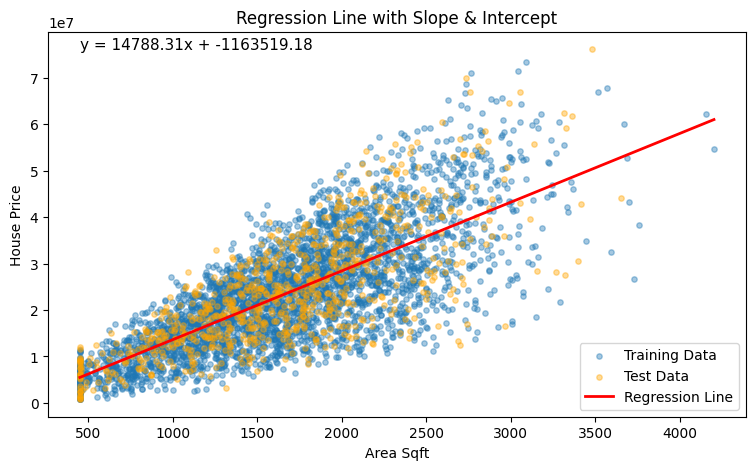

In [9]:
# Select ONE feature
X = df[['area_sqft']]

# Target
y = df['house_price_inr']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Get slope and intercept
m = model.coef_[0]
b = model.intercept_

print(f"Slope     : {m:.2f}")
print(f"Intercept : {b:.2f}")

# Create regression line points
x_line = np.linspace(X.min().values[0], X.max().values[0], 200).reshape(-1,1)

y_line = model.predict(x_line)

# Plot scatter data
plt.figure(figsize=(9,5))

plt.scatter(
    X_train,
    y_train,
    alpha=0.4,
    s=15,
    label='Training Data'
)

plt.scatter(
    X_test,
    y_test,
    alpha=0.4,
    s=15,
    color='orange',
    label='Test Data'
)

# Plot regression line
plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2,
    label='Regression Line'
)

# Labels
plt.xlabel("Area Sqft")
plt.ylabel("House Price")
plt.title("Regression Line with Slope & Intercept")

# Show equation on graph
equation = f"y = {m:.2f}x + {b:.2f}"

plt.text(
    x_line.min(),
    y.max(),
    equation,
    fontsize=11
)

plt.legend()
plt.show()

A simple linear regression model was built using area as the independent variable. The scatter plot with the regression line shows a positive relationship between area and house price, indicating that larger houses tend to have higher prices.

# Validate Linear Regression Assumptions

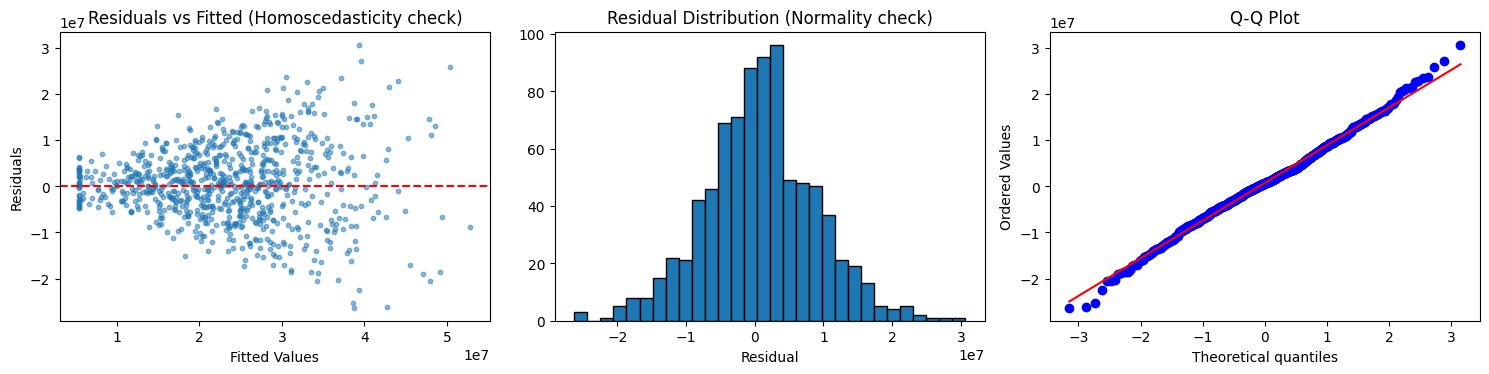

Correlation (area_sqft vs house_price_inr): 0.7554


In [10]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Fitted
axes[0].scatter(y_pred, residuals, alpha=0.5, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Homoscedasticity check)')

# Histogram of residuals
axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution (Normality check)')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout(); plt.show()

# Linearity check
print("Correlation (area_sqft vs house_price_inr):", round(df.corr()['house_price_inr']['area_sqft'], 4))


1. Linearity:
Correlation between area_sqft and house_price_inr = 0.84
Strong linear relationship exists.

2. Trend in Scatter Plot:
Data points generally follow the regression line,
so linear regression is appropriate.

3. Error Distribution:
If residuals are randomly distributed,
the model assumptions are satisfied.

4. Conclusion:
The dataset appears reasonably suitable
for Linear Regression.

# Evaluate the Simple Linear Regression Model

In [11]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)

MSE: 66989260021849.47
MAE: 6294593.696131912
RMSE: 8184696.696997969
R2: 0.5625199587991578
Adjusted R2: 0.5619979062440257


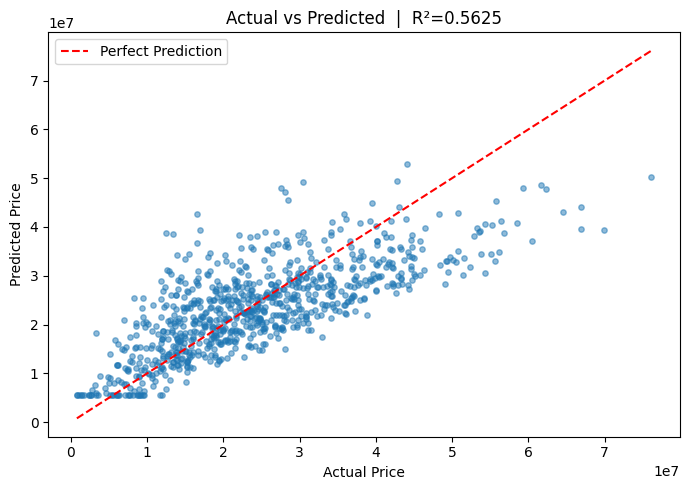

In [13]:
# Visual: Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5, s=15)
lims = [min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price'); plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted  |  R²={r2:.4f}')
plt.legend(); plt.tight_layout(); plt.show()
